In [114]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionInstructPix2PixPipeline,
    UNet2DConditionModel,
)


In [116]:
vae = AutoencoderKL.from_pretrained(
        "stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="vae")


In [195]:
from PIL import Image
import numpy as np
import torch

img_pil = Image.open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/rgb_static/0002.jpg").convert("RGB")
img = torch.tensor(np.array(img_pil)).unsqueeze(0).permute(0, 3, 1, 2) / 255.

In [196]:
img = img * 2 - 1 # Normalize to [-1, 1]

In [127]:
from diffusers.image_processor import VaeImageProcessor
vae_image_processor = VaeImageProcessor()

In [128]:
latent = vae.encode(img).latent_dist.sample()

In [129]:
latent.shape

torch.Size([1, 4, 25, 25])

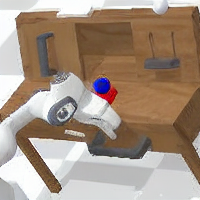

In [130]:
img_recon = vae.decode(latent).sample
img_recon = img_recon / 2 + 0.5  # Rescale to [0, 1]
img_recon = img_recon.clamp(0, 1)
img_recon = img_recon.squeeze(0).permute(1, 2, 0).detach().numpy() * 255
img_recon = img_recon.astype(np.uint8)
img_recon_pil = Image.fromarray(img_recon)
img_recon_pil

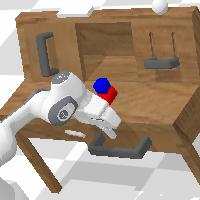

In [12]:
img_pil

In [183]:
from dawn.models.system1.raft import RAFT
flow = RAFT(flow_to_rgb=True)

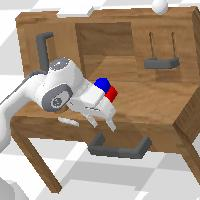

In [188]:
img2_pil = Image.open("/home/nero/Robotics/DAWN/data/calvin/dataset_opt/task_D_D/validation/episodes/659/rgb_static/0012.jpg").convert("RGB")
img2 = torch.tensor(np.array(img2_pil)).unsqueeze(0).permute(0, 3, 1, 2) / 255.
img2_pil

In [194]:
img.min()

tensor(-1.)

In [199]:
imgg = img
imgg2 = img2 * 2 - 1

In [200]:
this_flow = flow.gen_flow(torch.stack([imgg, imgg2], dim=1))

tensor(-1.) tensor(1.) torch.Size([1, 2, 3, 200, 200])


In [201]:
this_flow.shape

torch.Size([1, 3, 200, 200])

In [177]:
add = this_flow.mean(dim=1, keepdim=True)
this_flow = torch.cat([this_flow, add], dim=1)

In [202]:
this_flow.min()

tensor(0, dtype=torch.uint8)

In [203]:
this_flow.max()

tensor(255, dtype=torch.uint8)

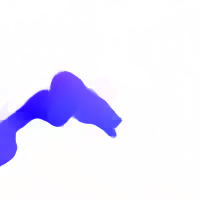

In [205]:
Image.fromarray((this_flow[0].permute(1, 2, 0).detach().numpy()).astype(np.uint8))

In [86]:
this_flow_norm = this_flow * 2 - 1 # Normalize to [-1, 1]

In [87]:
this_flow_norm.max()

tensor(1.)

In [88]:
latent_flow = vae.encode(this_flow_norm).latent_dist.sample()

In [89]:
flow_recon = vae.decode(latent_flow).sample

In [90]:
flow_recon = flow_recon / 2 + 0.5  # Rescale to [0, 1]
flow_recon = flow_recon.clamp(0, 1)

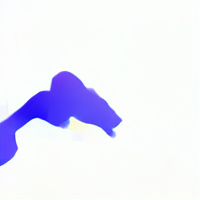

In [91]:
Image.fromarray((flow_recon[0].permute(1, 2, 0).detach().numpy() * 255).astype(np.uint8))

In [95]:
flow_recon.max()

tensor(1., grad_fn=<MaxBackward1>)

In [97]:
((flow_recon - this_flow)).sum()

tensor(-824.7208, grad_fn=<SumBackward0>)

In [51]:
diff = flow_recon - this_flow


(tensor(-0.2564, grad_fn=<MinBackward1>),
 tensor(0.2527, grad_fn=<MaxBackward1>))

In [98]:
import cv2
image1 = this_flow[0].permute(1, 2, 0).detach().numpy() * 255
image1 = image1.astype(np.uint8)
image2 = flow_recon[0].permute(1, 2, 0).detach().numpy() * 255
image2 = image2.astype(np.uint8)

difference = cv2.subtract(image1, image2)

# color the mask red
Conv_hsv_Gray = cv2.cvtColor(difference, cv2.COLOR_BGR2GRAY)
ret, mask = cv2.threshold(Conv_hsv_Gray, 0, 255,cv2.THRESH_BINARY_INV |cv2.THRESH_OTSU)
difference[mask != 255] = [0, 0, 255]

# add the red mask to the images to make the differences obvious
image1[mask != 255] = [0, 0, 255]
image2[mask != 255] = [0, 0, 255]


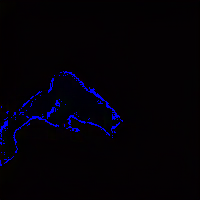

In [100]:
Image.fromarray(difference)

In [102]:
np.array(img_pil)

array([[[221, 221, 221],
        [221, 221, 221],
        [221, 221, 221],
        ...,
        [251, 255, 255],
        [249, 255, 255],
        [249, 255, 255]],

       [[221, 221, 221],
        [221, 221, 221],
        [221, 221, 221],
        ...,
        [242, 247, 251],
        [244, 249, 253],
        [246, 254, 255]],

       [[221, 221, 221],
        [221, 221, 221],
        [221, 221, 221],
        ...,
        [254, 255, 255],
        [252, 255, 255],
        [251, 255, 255]],

       ...,

       [[177, 177, 177],
        [176, 176, 176],
        [176, 176, 176],
        ...,
        [234, 234, 234],
        [234, 234, 234],
        [231, 231, 231]],

       [[177, 177, 177],
        [177, 177, 177],
        [176, 176, 176],
        ...,
        [254, 254, 254],
        [246, 246, 246],
        [234, 234, 234]],

       [[177, 177, 177],
        [177, 177, 177],
        [177, 177, 177],
        ...,
        [255, 255, 255],
        [241, 241, 241],
        [221, 221, 221]]

In [109]:
from transformers import AutoModel

In [112]:
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5")


Loading pipeline components...: 100%|██████████| 7/7 [00:04<00:00,  1.70it/s]


In [113]:
pipe

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.33.1",
  "_name_or_path": "stable-diffusion-v1-5/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}